# Проект: Система антифрода транзакций для цифрового ритейла

---

# 1. Источник и состав данных

## Обзор источника
Ссылка на данные: [IEEE-CIS Fraud Detection (Kaggle)](https://www.kaggle.com/competitions/ieee-fraud-detection/overview)  
Данные предоставлены компанией **Vesta Corporation** в рамках соревнования IEEE-CIS Fraud Detection. Датасет представляет собой поток реальных анонимизированых транзакций.

**Vesta Corporation** — ведущий мировой эксперт в области защиты платежей и предотвращения мошенничества в сфере электронной коммерции. Компания специализируется на транзакциях типа Card Not Present (картой без присутствия — онлайн платежи), работает с клиентами в 40 странах. Несмотря на то, что в настоящее время Vesta Corporation фокусируется на телекоммуникационном секторе, предоставленный датасет охватывает более широкий спектр электронной коммерции и цифровых товаров.

## Структура и состав данных

Для данного проекта я использую 2 файла в csv формате:
*   **train_transaction** 
*   **train_identity** 

Таблицы `identity` и `transaction`, объединяются по ключу `TransactionID`.
Не все транзакции (`transaction`) имеют соответствующую идентификационную (`identity`) информацию. 

Файлы из набора данных, кторые я не использую: 
*   `test_transaction` и `test_identity`, так как в тестовой выборке остутствует таргет. 
*   `sample_submission` содержит только id транзакций, для которых нужно сделать предсказание.

### Таблица транзакций (transaction)
Содержат основную информацию о платежной операции:

*   **TransactionID**: Уникальный идентификатор транзакции.
*   **TransactionDT**: Временной интервал (timedelta) относительно заданной базовой даты (не является фактической меткой времени).
*   **TransactionAMT**: Сумма платежа в долларах США (USD).
*   **ProductCD**: Код продукта; категория товара или услуги для каждой транзакции.
*   **card1 – card6**: Информация о платежной карте: тип карты (дебетовая/кредитная), категория (gold, platinum), банк-эмитент, страна выпуска и т.д.
*   **addr1**: регион выставления счетов, 
*   **addr2**: страна выставления счетов.
*   **dist**: Расстояние (может означать дистанцию между адресом доставки, биллинга или IP).
*   **P_emaildomain** и **R_emaildomain**: Домены электронной почты покупателя (purchaser) и получателя (recipient).
*   **C1–C14**: Счетчики. Например, количество адресов, связанных с данной картой. Реальные значения признаков скрыты (маскированы).
*   **D1–D15**: Временные дельты (timedelta), например, количество дней между текущей и предыдущей транзакциями.
*   **M1–M9**: Признаки совпадения (match). Например, совпадает ли имя на карте с адресом доставки и т.д.
*   **V1 — V339**: Богатый набор признаков, созданных инженерами Vesta (engineered features). Включает в себя ранжирование, счетчики и другие типы связей между объектами.

**Категориальные признаки (Categorical Features):**
*   ProductCD 
*   card1 - card6
*   addr1, addr2
*   P_emaildomain, R_emaildomain
*   M1 - M9



### Таблица идентичности (identity)
Содержат сетевые атрибуты и информацию об устройстве покупателя:

*   **TransactionID**: Уникальный идентификатор транзакции.
*   **DeviceType**: Тип устройства (mobile или desktop).
*   **DeviceInfo**: Детальная информация об устройстве (модель телефона, версия ОС или браузера).
*   **id_01 — id_38**: Технические параметры (разрешение экрана, использование прокси-серверов, системный язык, IP-адрес и другие цифровые отпечатки).

**Категориальные признаки (Categorical Features):**
*   DeviceType 
*   DeviceInfo
*   id_12 — id_38
---

# 2. EDA

## Загрузка данных

In [1]:
# Ячейка для импорта всех библиотек, используемых в данном ноутбуке
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Загрузка данных
print("Загрузка данных...")
transaction = pd.read_csv('data/raw/train_transaction.csv')
identity = pd.read_csv('data/raw/train_identity.csv')
print("Данные загружены.")

Загрузка данных...
Данные загружены.


In [3]:
print(f"Размер таблицы transaction: {transaction.shape}")
print(f"Размер таблицы identity: {identity.shape}")

Размер таблицы transaction: (590540, 394)
Размер таблицы identity: (144233, 41)


In [4]:
with pd.option_context('display.max_columns', None):
    display(transaction.head())

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M0,T,T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,

In [5]:
transaction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 394 entries, TransactionID to V339
dtypes: float64(376), int64(4), object(14)
memory usage: 1.7+ GB


In [6]:
with pd.option_context('display.max_columns', None):
    display(identity.head())

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,NotFound,NaN,-480.0,New,NotFound,166.0,NaN,542.0,144.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,NaN,100.0,NotFound,49.0,-300.0,New,NotFound,166.0,NaN,621.0,500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,iOS 11.1.2,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,100.0,NotFound,52.0,NaN,Found,Found,121.0,NaN,410.0,142.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,NaN,100.0,NotFound,52.0,NaN,New,NotFound,225.0,NaN,176.0,507.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,0.0,100.0,NotFound,NaN,-300.0,Found,Found,166.0,15.0,529.0,575.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,Mac OS X 10_11_6,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


In [7]:
identity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144233 entries, 0 to 144232
Data columns (total 41 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionID  144233 non-null  int64  
 1   id_01          144233 non-null  float64
 2   id_02          140872 non-null  float64
 3   id_03          66324 non-null   float64
 4   id_04          66324 non-null   float64
 5   id_05          136865 non-null  float64
 6   id_06          136865 non-null  float64
 7   id_07          5155 non-null    float64
 8   id_08          5155 non-null    float64
 9   id_09          74926 non-null   float64
 10  id_10          74926 non-null   float64
 11  id_11          140978 non-null  float64
 12  id_12          144233 non-null  object 
 13  id_13          127320 non-null  float64
 14  id_14          80044 non-null   float64
 15  id_15          140985 non-null  object 
 16  id_16          129340 non-null  object 
 17  id_17          139369 non-nul

In [8]:
with pd.option_context('display.max_columns', None):
    display(identity.describe())

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_13,id_14,id_17,id_18,id_19,id_20,id_21,id_22,id_24,id_25,id_26,id_32
count,1.442330e+05,144233.000000,140872.000000,66324.000000,66324.000000,136865.000000,136865.000000,5155.000000,5155.000000,74926.000000,74926.000000,140978.000000,127320.000000,80044.000000,139369.000000,45113.000000,139318.000000,139261.000000,5159.000000,5169.000000,4747.000000,5132.000000,5163.000000,77586.000000
mean,3.236329e+06,-10.170502,174716.584708,0.060189,-0.058938,1.615585,-6.698710,13.285354,-38.600388,0.091023,-0.301124,99.745325,48.053071,-344.507146,189.451377,14.237337,353.128174,403.882666,368.269820,16.002708,12.800927,329.608924,149.070308,26.508597
std,1.788496e+05,14.347949,159651.816856,0.598231,0.701015,5.249856,16.491104,11.384207,26.084899,0.983842,2.789446,1.127602,11.774858,93.695502,30.375360,1.561302,141.095343,152.160327,198.847038,6.897665,2.372447,97.461089,32.101995,3.737502
min,2.987004e+06,-100.000000,1.000000,-13.000000,-28.000000,-72.000000,-100.000000,-46.000000,-100.000000,-36.000000,-100.000000,90.000000,10.000000,-660.000000,100.000000,10.000000,100.000000,100.000000,100.000000,10.000000,11.000000,100.000000,100.000000,0.000000
25%,3.077142e+06,-10.000000,67992.000000,0.000000,0.000000,0.000000,-6.000000,5.000000,-48.000000,0.000000,0.000000,100.000000,49.000000,-360.000000,166.000000,13.000000,266.000000,256.000000,252.000000,14.000000,11.000000,321.000000,119.000000,24.000000
50%,3.198818e+06,-5.000000,125800.500000,0.000000,0.000000,0.000000,0.000000,14.000000,-34.000000,0.000000,0.000000,100.000000,52.000000,-300.000000,166.000000,15.000000,341.000000,472.000000,252.000000,14.000000,11.000000,321.000000,149.000000,24.000000
75%,3.392923e+06,-5.000000,228749.000000,0.000000,0.000000,1.000000,0.000000,22.000000,-23.000000,0.000000,0.000000,100.000000,52.000000,-300.000000,225.000000,15.000000,427.000000,533.000000,486.500000,14.000000,15.000000,371.000000,169.000000,32.000000
max,3.577534e+06,0.000000,999595.000000,10.000000,0.000000,52.000000,0.000000,61.000000,0.000000,25.000000,0.000000,100.000000,64.000000,720.000000,229.000000,29.000000,671.000000,661.000000,854.000000,44.000000,26.000000,548.000000,216.000000,32.000000


## Расчет количества и доли фрода

In [9]:
# Расчет количества и доли фродовых операций
fraud_counts = transaction['isFraud'].value_counts()
fraud_rate = transaction['isFraud'].value_counts(normalize=True) * 100

# Формирование итоговой таблицы
stats_df = pd.DataFrame({
    'Количество': fraud_counts,
    'Доля (%)': round(fraud_rate,2)
})

stats_df

,Количество,Доля (%)
isFraud,,
0,569877,96.5
1,20663,3.5


## Проверка на дубли

In [11]:
# Проверка уникальности ключа TransactionID
id_duplicates_trans = transaction['TransactionID'].duplicated().sum()
print(f"Дубликатов по TransactionID в таблице transaction: {id_duplicates_trans}")

id_duplicates_id = identity['TransactionID'].duplicated().sum()
print(f"Дубликатов по TransactionID в таблице identity: {id_duplicates_id}")

Дубликатов по TransactionID в таблице transaction: 0
Дубликатов по TransactionID в таблице identity: 0


## Проверка пропусков данных

### Таблица transaction

In [12]:
# Расчет пропусков в таблице transaction
nan_count = transaction.isnull().sum()
nan_rate = (transaction.isnull().sum() / len(transaction)) * 100
limit = 50
missing_data = nan_rate[nan_rate > limit].index

print(f"Количество колонок, где пропусков > {limit}%: {len(missing_data)}")

# Формируем таблицу для анализа
nan_df = pd.DataFrame({
    'Количество NaN': nan_count,
    'Доля NaN (%)': nan_rate
}).sort_values(by='Доля NaN (%)', ascending=False)

n = 10
print(f"\nТоп-{n} признаков по количеству пропусков")
nan_df.head(n)

Количество колонок, где пропусков > 50%: 174

Топ-10 признаков по количеству пропусков


,Количество NaN,Доля NaN (%)
dist2,552913,93.628374
D7,551623,93.409930
D13,528588,89.509263
D14,528353,89.469469
D12,525823,89.041047
D6,517353,87.606767
D9,515614,87.312290
D8,515614,87.312290
V153,508595,86.123717
V139,508595,86.123717


### Таблица identity

In [13]:
# Расчет пропусков в таблице identity
nan_count = identity.isnull().sum()
nan_rate = (identity.isnull().sum() / len(identity)) * 100
limit = 50
missing_data = nan_rate[nan_rate > limit].index

print(f"Количество колонок, где пропусков > {limit}%: {len(missing_data)}")

# Формируем таблицу для анализа
nan_df = pd.DataFrame({
    'Количество NaN': nan_count,
    'Доля NaN (%)': nan_rate
}).sort_values(by='Доля NaN (%)', ascending=False)

n = 10
print(f"\nТоп-{n} признаков по количеству пропусков")
nan_df.head(n)

Количество колонок, где пропусков > 50%: 12

Топ-10 признаков по количеству пропусков


,Количество NaN,Доля NaN (%)
id_24,139486,96.708798
id_25,139101,96.441868
id_07,139078,96.425922
id_08,139078,96.425922
id_21,139074,96.423149
id_26,139070,96.420375
id_23,139064,96.416215
id_27,139064,96.416215
id_22,139064,96.416215
id_18,99120,68.722137


## Первичные выводы
*   Наблюдается характерный для задачи антифрода сильный дисбаланс классов: доля фрода - 3,5% от всех операций.
*   Размер таблицы `identity`— 144 233 строк (считая с 0), в то время как у таблици `transaction`— 590 540 строк. Отсутствие данных об устройстве — важный сигнал, который может указывать как на техническую специфику, так и на попытку скрыть личность.
*   Большинство признаков скрыто (V, C, D, id).
*   Наличие 434 признаков требует в дальнейшем проведения этапа отбора признаков.
*   Дубликаты по ключу `TransactionID` отсутствуют. 
*   Наблюдается высокая доля пропусков (> 90% в некоторых признаках). 

### Стратегия обработки пропусков 

**Принятые решения:**
1. **Отказ от заполнения:** Средние значения или мода не используются, так как отсутствие данных в антифроде является самостоятельным признаком (индикатором анонимизации).
2. **Алгоритмическая обработка:** Выбранный классификатор **CatBoost** обрабатывает `NaN` нативно, учитывая их при построении сплитов в деревьях.
3. **Feature Engineering:** Стоит рассмотреть создание синтетического признака `nan_count` (количество пустых полей в транзакции). Гипотеза: аномально высокое или низкое количество метаданных может указывать на автоматизированные скрипты атак.
4. **Фильтрация:** Признаки, содержащие более 90% пропусков и не имеющие бизнес-смысла, стоит удалить.

## Анализ временных рядов

### Распределение фрода по часам суток

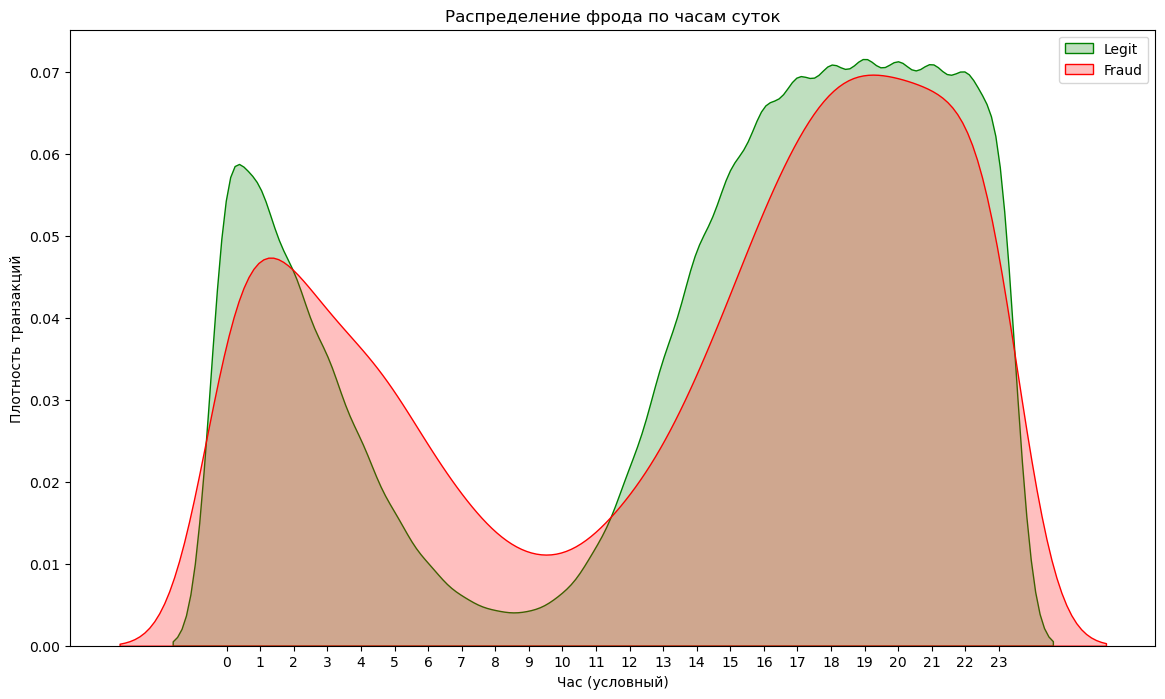

In [14]:
plt.figure(figsize=(14, 8))

# TransactionDT — это секунды (гипотеза). Посчитаем "день" и "час"
hour_legit = (transaction.loc[transaction['isFraud'] == 0, 'TransactionDT'] // 3600) % 24
hour_fraud = (transaction.loc[transaction['isFraud'] == 1, 'TransactionDT'] // 3600) % 24

# Строим графики
sns.kdeplot(hour_legit, label='Legit', fill=True, color='green')
sns.kdeplot(hour_fraud, label='Fraud', fill=True, color='red')

plt.title('Распределение фрода по часам суток')
plt.xlabel('Час (условный)')
plt.ylabel('Плотность транзакций')
plt.xticks(range(0, 24))
plt.legend()
plt.show()

### Интерпретация суточной цикличности

Поставщик данных не предоставил информацию о времени и датах, всё что известно это то, что `TransactionDT` временной интервал (timedelta) относительно заданной базовой даты (не является фактической меткой времени).  
Несмотря на отсутствие информации, анализ выявил четкую суточную периодичность (цикл 86 400 сек). Так же можно предположить, что точка отсчёта от которой считается значение `TransactionDT` — это полночь по UTC (Всемирное координированное время), в таком случае, интервал 2 - 11 соответствует ночному времени в Восточном часовом поясе США (UTC-5 зимнее время/ UTC-4 летнее время), где проживает около 50% всего населения страны.


### Интерпретация графика KDE
На графике отображена плотность распределения транзакций по часам суток для каждого класса отдельно. 

* **Ось Y (Density):** Отражает относительную концентрацию транзакций. Площадь под каждой кривой нормализована к единице, что позволяет сравнивать паттерны поведения групп разного объема (3.5% фрода против 96.5% легитимных операций).
* **Анализ паттернов:** Смещение "красного холма" (Fraud) относительно "зеленого" (Legit) указывает на временные интервалы повышенного риска. 


Визуализация плотности распределения по 24-часовому циклу показывает наличие сильной зависимости между временем совершения операции и риском мошенничества.

**Ключевые выводы:**
* **Интервал высокого риска (2 — 11):** Наблюдается значительное превышение плотности фрода над легитимным трафиком. В этот период (предположительно ночные часы в США) совершается минимальное количество покупок реальными пользователями, что делает любую активность в этом окне подозрительной.
* **Зона мимикрии (17 — 22):** Пик абсолютной активности мошенников совпадает с часами наибольшей нагрузки на систему. Это классическая стратегия "затеряться в толпе".
* **Асимметрия затухания (23):** Легитимный трафик затухает быстрее мошеннического, что создает дополнительное окно риска в конце суток.

### Анализ доли фрода в зависимости от часа суток

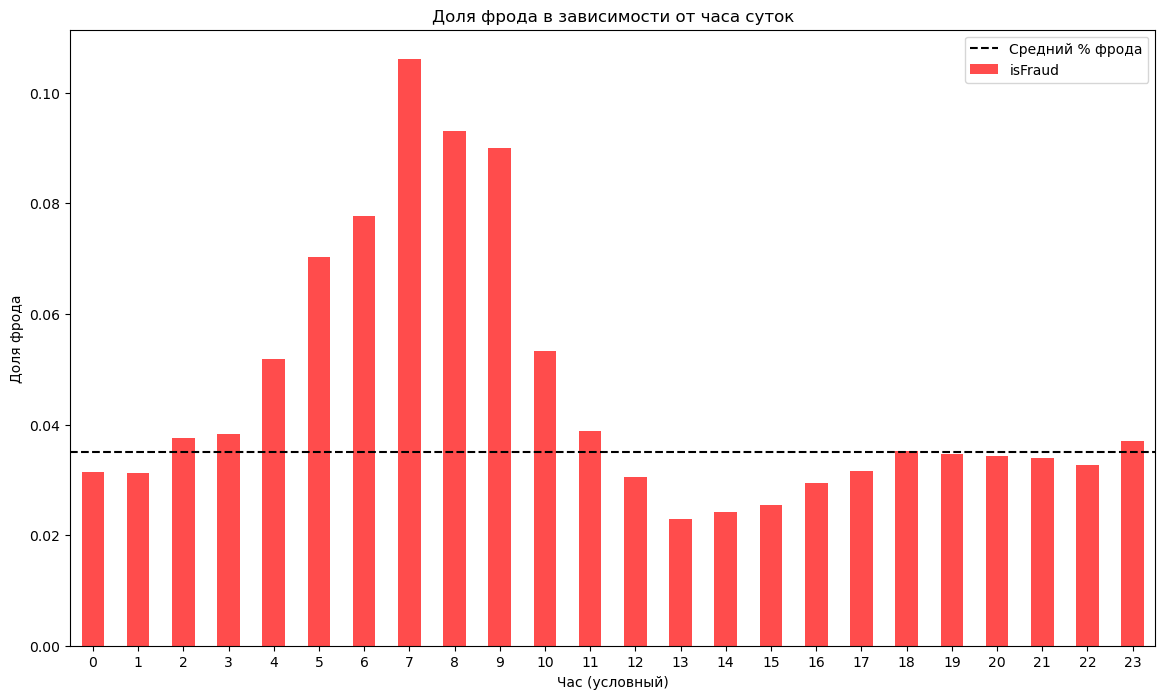

In [15]:
# Считаем долю фрода для каждого часа
temp_df = pd.DataFrame({
    'hour': (transaction['TransactionDT'] // 3600) % 24,
    'isFraud': transaction['isFraud']
})

fraud_by_hour = temp_df.groupby('hour')['isFraud'].mean()

plt.figure(figsize=(14, 8))
fraud_by_hour.plot(kind='bar', color='red', alpha=0.7)
plt.axhline(transaction.isFraud.mean(), color='black', linestyle='--', label='Средний % фрода')
plt.title('Доля фрода в зависимости от часа суток')
plt.xlabel('Час (условный)')
plt.ylabel('Доля фрода')
plt.xticks(rotation=0)
plt.legend()
plt.show()

Данный график демонстрирует конверсию общего трафика во фрод в зависимости от часа. 

**Ключевые выводы:**
* **Аномальный риск:** В интервале **02 — 11** доля фрода выше среднего значения 3,5%. Несмотря на то, что транзакций в эти часы не много (согласно предыдущему KDE-графику), удельный вес мошеннических операций здесь критичен.
* В **23** часа также есть небольшое превышение доли фрода над среднем значением.


### Примечание о технической достоверности часа 23
Зафиксированный всплеск доли фрода в 23-й час требует осторожной интерпретации. 

**Возможные причины:**
1. **Технический артефакт:** Особенности пакетной обработки данных (batching) на стороне шлюза Vesta или погрешность алгоритма анонимизации временных меток.
2. **Логическая граница:** Завершение расчетного цикла суток, в который попадают транзакции, требовавшие длительной верификации.

**Решение:** Несмотря на возможную техническую природу всплеска, признак сохраняется для обучения модели, так как он обладает высокой предсказательной силой в рамках данного датасета. Однако при внедрении в реальный продакшн SME-ритейла данный интервал потребует дополнительной калибровки.


### Анализ плотности распределения транзакций по дням недели

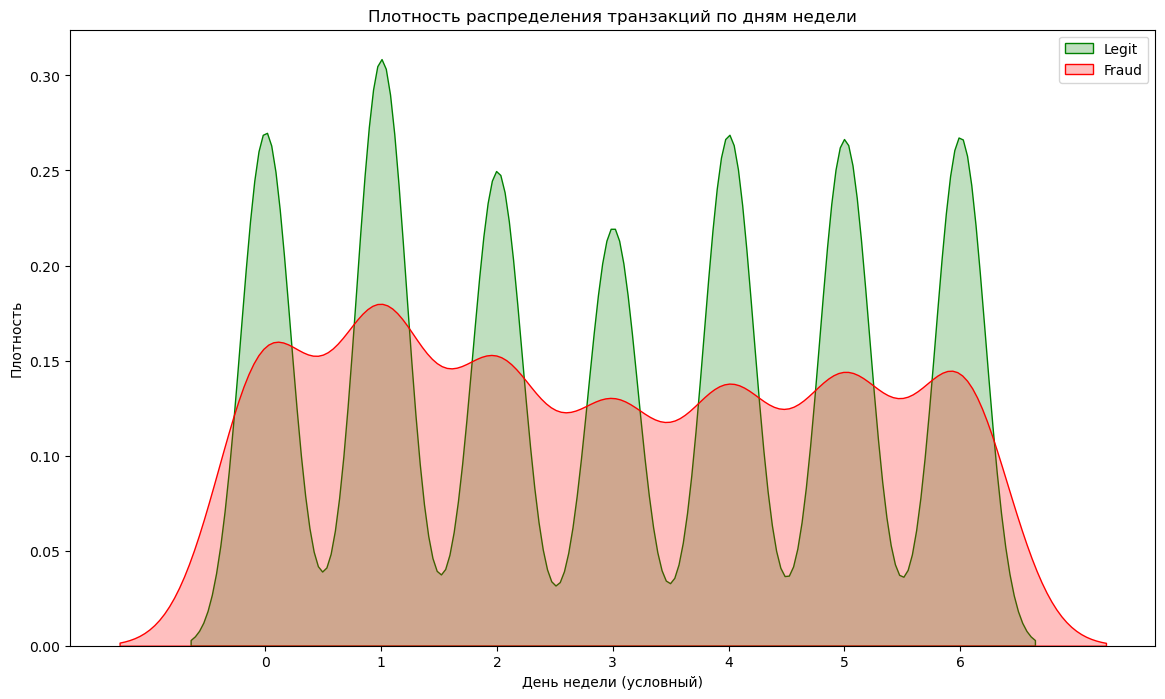

In [16]:
plt.figure(figsize=(14, 8))

# Считаем день недели (от 0 до 6) 
# TransactionDT // 86400 дает количество полных дней
days_legit = (transaction.loc[transaction['isFraud'] == 0, 'TransactionDT'] // 86400) % 7
days_fraud = (transaction.loc[transaction['isFraud'] == 1, 'TransactionDT'] // 86400) % 7

# Визуализация плотности
sns.kdeplot(days_legit, label='Legit', fill=True, color='green', bw_adjust=1.5)
sns.kdeplot(days_fraud, label='Fraud', fill=True, color='red', bw_adjust=1.5)

plt.title('Плотность распределения транзакций по дням недели')
plt.xlabel('День недели (условный)')
plt.ylabel('Плотность')
plt.xticks(range(7)) 
plt.legend()
plt.show()

График плотности распределения по дням недели выявил ключевое различие в поведении классов:

* **Легитимный трафик (Зеленый):** Демонстрирует жесткую привязку к суточному ритму. Глубокие "провалы" между пиками соответствуют ночным часам, когда активность покупателей минимальна.
* **Мошенническая активность (Красный):** Красная кривая значительно более "сглажена" — это означает, что фрод-транзакции совершаются более равномерно, в том числе в периоды, когда обычные пользователи неактивны.
* **Аномальные зоны:** В моменты ночных минимумов легитимного трафика плотность фрода остается аномально высокой.

**Бизнес-вывод:** Мошенники используют автоматизированные средства (ботов), которые работают круглосуточно, что позволяет системе идентифицировать их по отсутствию естественных "биологических" пауз в активности.

### Анализ вероятности фрода по дням недели

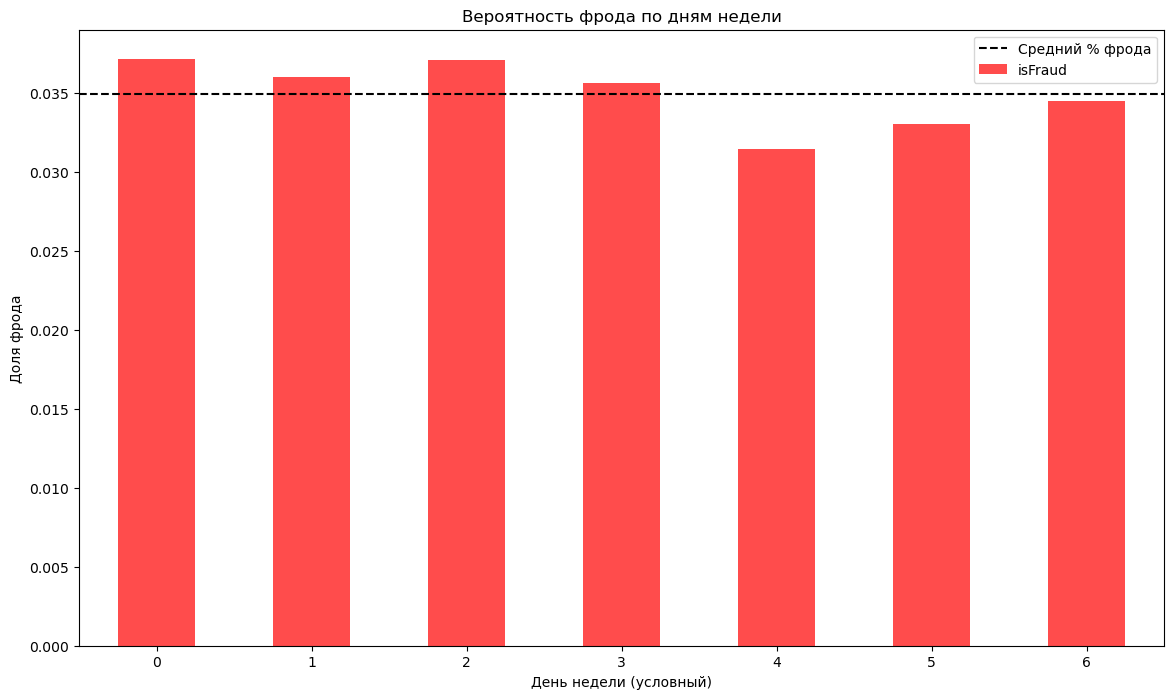

In [17]:
# В неделе 604800 секунд (86400 * 7)
# Считаем день недели 
day_legit = (transaction.loc[transaction['isFraud'] == 0, 'TransactionDT'] // 86400) % 7
day_fraud = (transaction.loc[transaction['isFraud'] == 1, 'TransactionDT'] // 86400) % 7

plt.figure(figsize=(14, 8))

# Считаем долю фрода для каждого дня
temp_df = pd.DataFrame({
    'day': (transaction['TransactionDT'] // 86400) % 7,
    'isFraud': transaction['isFraud']
})
fraud_by_day = temp_df.groupby('day')['isFraud'].mean()

# Визуализация
ax = fraud_by_day.plot(kind='bar', color='red', alpha=0.7)
plt.axhline(transaction.isFraud.mean(), color='black', linestyle='--', label='Средний % фрода')

plt.title('Вероятность фрода по дням недели')
plt.xlabel('День недели (условный)')
plt.ylabel('Доля фрода')
plt.xticks(range(7), rotation=0)
plt.legend()
plt.show()

del temp_df

Судя по распределению вероятности, условный "День 0" не является понедельником.

**Ключевые выводы:**
* **Период повышенного риска (Дни 0-3):** В начале цикла наблюдается устойчивое превышение среднерыночного уровня фрода (3.5%). Это указывает на систематические атаки в данные периоды.
* **Период сниженного риска (Дни 4-5):** Наблюдается статистически значимое снижение доли мошеннических операций. 
* Недельная цикличность выражена слабее суточной.


## Анализ сумм транзакций

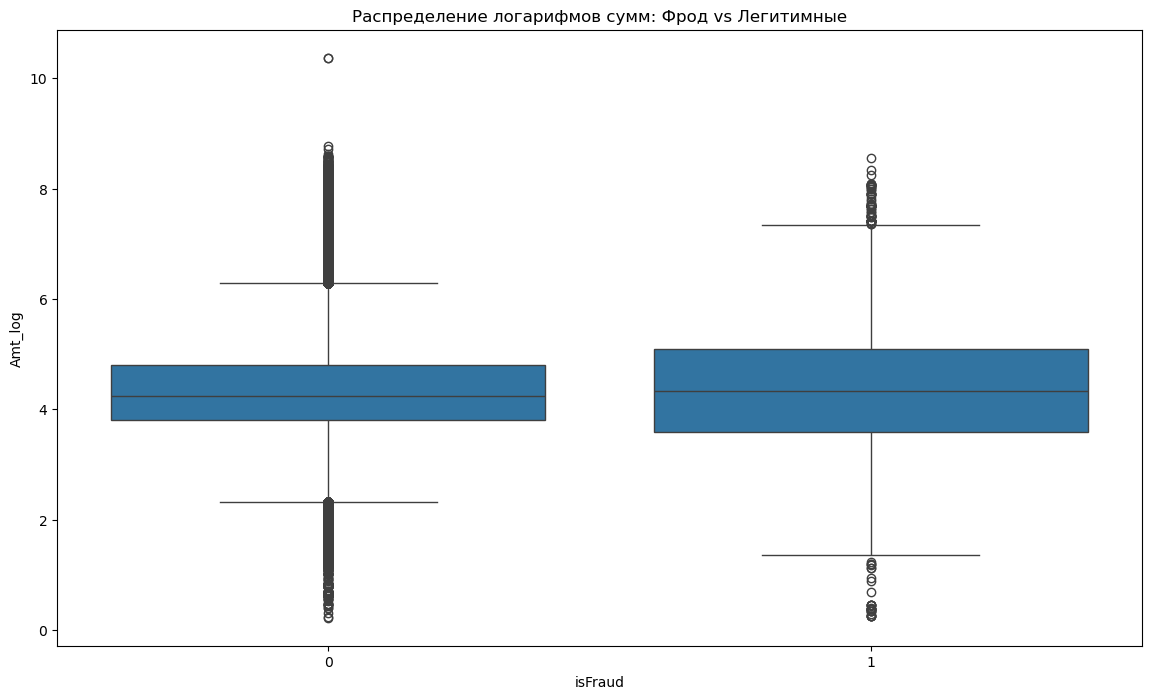

,mean,median,std
isFraud,,,
0,134.511665,68.5,239.395078
1,149.244779,75.0,232.212163


In [18]:
# Посмотрим на распределение сумм через логарифм (так как разброс огромный)
transaction['Amt_log'] = np.log1p(transaction['TransactionAmt'])

plt.figure(figsize=(14, 8))
sns.boxplot(x='isFraud', y='Amt_log', data=transaction)
plt.title('Распределение логарифмов сумм: Фрод vs Легитимные')
plt.show()

# Статистика по суммам
display(transaction.groupby('isFraud')['TransactionAmt'].agg(['mean', 'median', 'std']))


transaction.drop('Amt_log', axis=1, inplace=True)

Для корректной визуализации данных с учетом огромного разброса сумм (от центов до десятков тысяч долларов) было применено логарифмическое преобразование (`np.log1p`).

**Ключевые выводы:**
* **Средний чек:** У мошеннических транзакций средний чек выше (＄149.2) по сравнению с легитимными (＄134.5). Это говорит о том, что злоумышленники стремятся максимизировать выгоду с каждой скомпрометированной карты.
* **Медианные значения:** Медиана фрода (＄75.0) также превышает медиану обычных покупок (＄68.5).
* **Аномалии (Outliers):** В обеих группах наблюдается большое количество выбросов, что характерно для цифрового ритейла (от дешевых подписок до дорогой электроники).

**Вывод для моделирования:**
Сумма транзакции является значимым, но не самодостаточным признаком. Модели необходимо учитывать `TransactionAmt` в связке с категорией товара (`ProductCD`), так как аномальность суммы сильно зависит от контекста покупки. Использование логарифмированной суммы в качестве признака поможет модели стабильнее работать с экстремальными значениями.


## Анализ риска по категориям товаров

In [19]:
def eda_analysis(df, column, title_name, is_top=False, n_top=10, rotation=0):
    """
    Функция для визуализации объема транзакций и уровня фрода по категориям.
    """
    # 1. Подготовка данных
    if is_top:
        top_values = df[column].value_counts().nlargest(n_top).index
        temp_df = df[df[column].isin(top_values)].copy()
    else:
        temp_df = df.copy()
        
    stats = temp_df.groupby(column)['isFraud'].agg(['count', 'mean']).reset_index()
    stats.columns = [column, 'TotalTransactions', 'FraudRate']
    stats = stats.sort_values(by='FraudRate', ascending=False)

    # 2. Визуализация
    fig, ax1 = plt.subplots(figsize=(14, 8))

    # Столбчатая диаграмма - Объем (Количество)
    sns.barplot(
        x=column, 
        y='TotalTransactions', 
        data=stats, 
        ax=ax1,  
        color='skyblue',
        legend=False
    )
    ax1.set_ylabel('Общее количество транзакций', color='blue', fontsize=12)
    ax1.set_title(f'Анализ {title_name}: Объем vs Риск', fontsize=14)
    ax1.tick_params(axis='x', rotation=rotation)

    # Линейный график - Риск (Fraud Rate)
    ax2 = ax1.twinx()
    sns.lineplot(
        x=stats[column].astype(str), # приведение к строке для корректной оси
        y=stats['FraudRate'], 
        ax=ax2, 
        marker='o', 
        color='red', 
        lw=3
    )
    ax2.set_ylabel('Доля фрода (Fraud Rate)', color='red', fontsize=12)
    
    # Линия среднего уровня фрода по всему датасету
    mean_fraud = df['isFraud'].mean()
    ax2.axhline(mean_fraud, color='black', linestyle='--', alpha=0.5, label=f'Средний фрод ({mean_fraud:.2%})')

    plt.tight_layout()
    plt.show()
    
    return stats

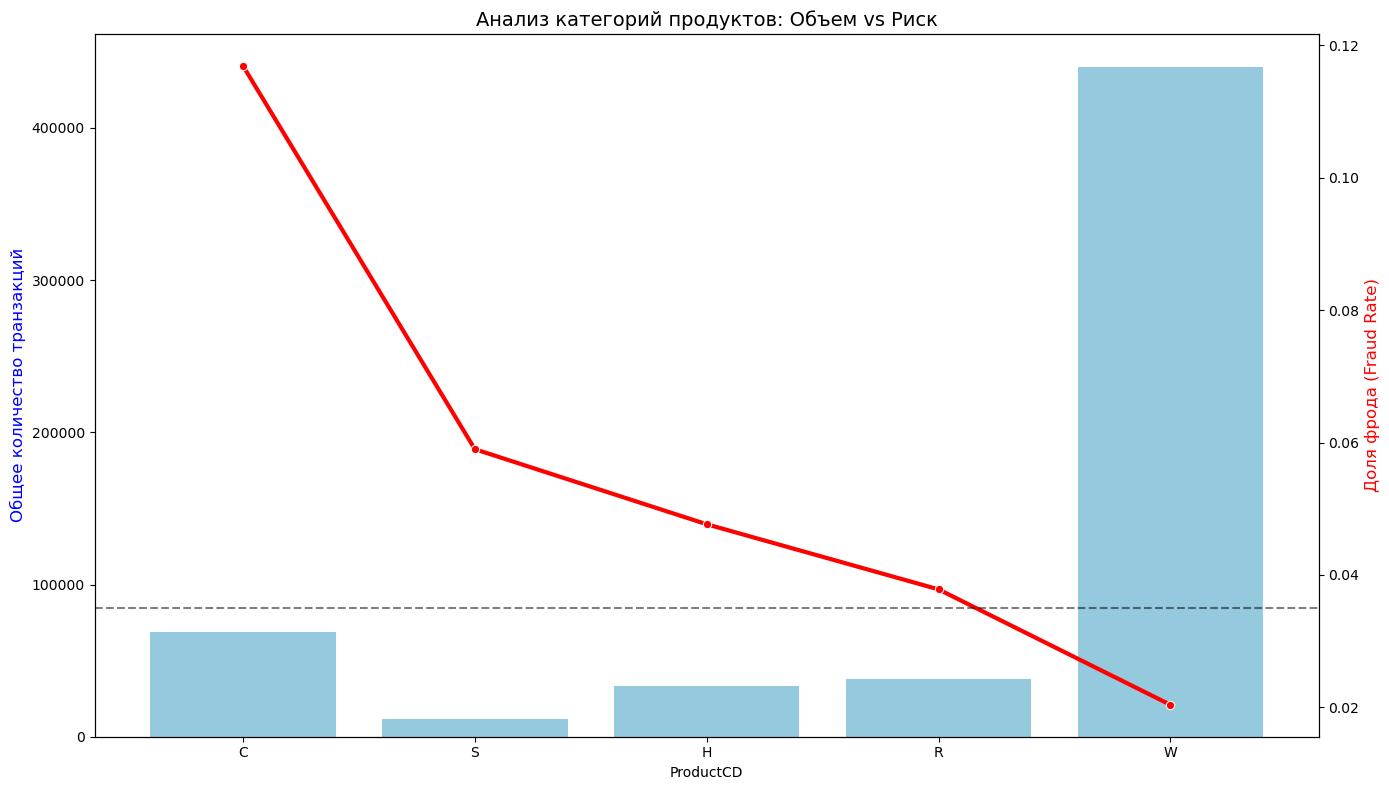

,ProductCD,TotalTransactions,FraudRate
0,C,68519,0.116873
3,S,11628,0.058996
1,H,33024,0.047662
2,R,37699,0.037826
4,W,439670,0.020399


In [20]:
product_stats = eda_analysis(transaction, 'ProductCD', 'категорий продуктов')
display(product_stats)

Признак `ProductCD` отражает тип приобретаемого продукта. Сравнение общего объема транзакций с фактической долей мошенничества позволило сегментировать категории по уровню риска.

**Ключевые выводы:**
* **Высокорисковые категории:** Категории **C** и **S** (предположительно, цифровые товары и подарочные карты) демонстрируют аномально высокую долю фрода, значительно превышающую средний уровень по датасету (3.5%).
* **Безопасные категории:** Категория **W** (вероятно, "World" или стандартный ритейл) является самой массовой и при этом самой чистой с точки зрения мошенничества.
* **Специфика атак:** Мошенники целенаправленно выбирают специфические категории товаров.


## Анализ платежных систем (card4)

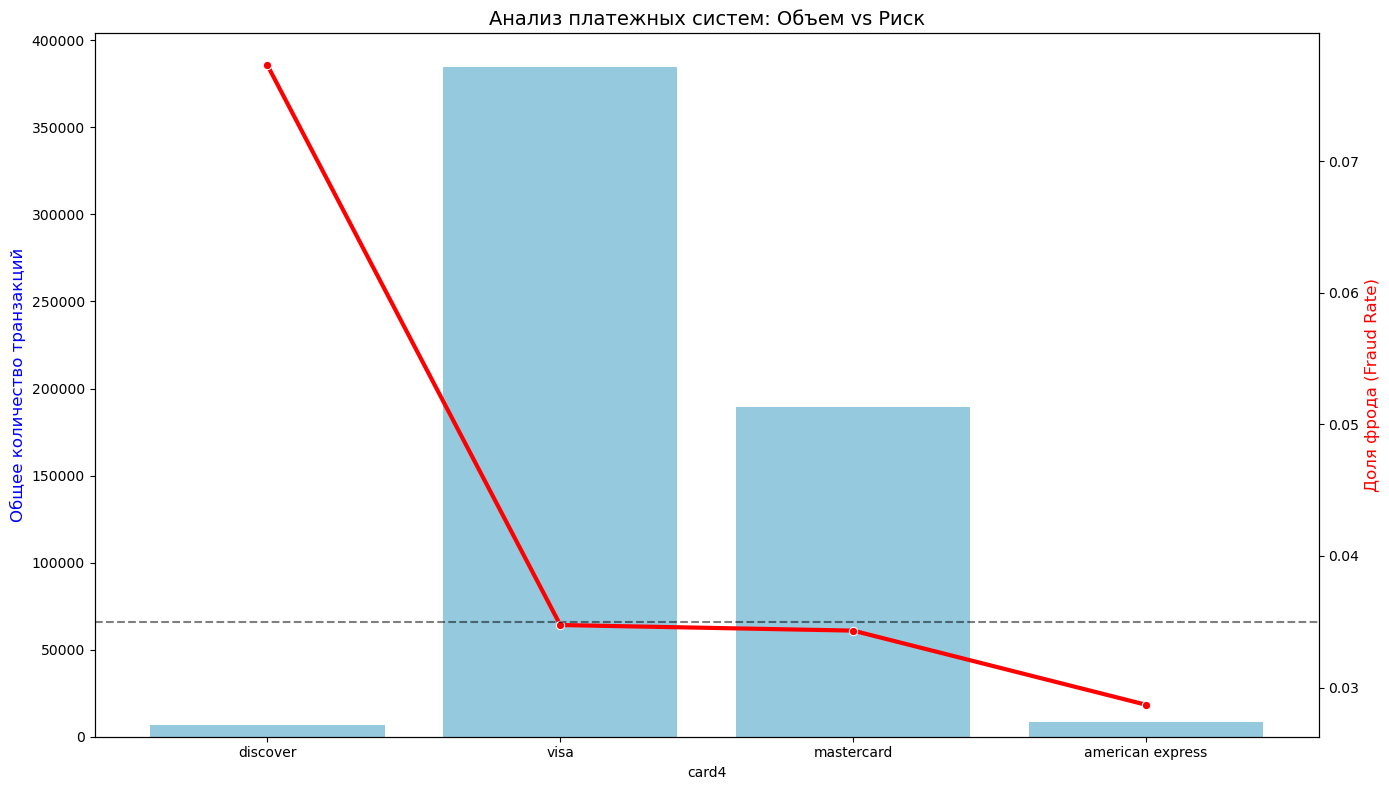

,card4,TotalTransactions,FraudRate
1,discover,6651,0.077282
3,visa,384767,0.034756
2,mastercard,189217,0.034331
0,american express,8328,0.028698


In [21]:
# анализ платежных систем (Visa, Mastercard и т.д.)
card4_stats = eda_analysis(transaction, 'card4', 'платежных систем')
display(card4_stats)

Визуализация соотношения объема транзакций к уровню риска выявила следующие закономерности:

*   **Аномалия Discover:**
    *   Доля фрода (FraudRate): 7.7%. Это более чем в 2 раза выше, чем в среднем по датасету (3.5%).
    *   При этом объем транзакций минимален (~6.6 тыс. операций).
    *   **Вывод:** В рамках данного датасета Discover является «магнитом» для фрода. Это может быть связано с менее строгими протоколами проверки в этой сети на момент сбора данных.

*   **Visa и Mastercard (Масс-маркет):**
    *   Суммарно занимают около 97% всего объема транзакций.
    *   Уровень фрода практически идентичен и колеблется в районе 3.4% – 3.5%.
    *   **Вывод:** Это «базовый» уровень шума для масс-маркета. Для этих систем модель не сможет опираться только на тип карты и будет искать более сложные зависимости (время, IP, поведение).

*   **American Express (Самая безопасная):**
    *   Демонстрирует самый низкий риск — 2.8%.
    *   **Вывод:** Это соответствует рыночной логике: карты AMEX чаще принадлежат премиальному сегменту и имеют жесткий внутренний антифрод на стороне банка-эмитента.

## Анализ типов карт (card6)

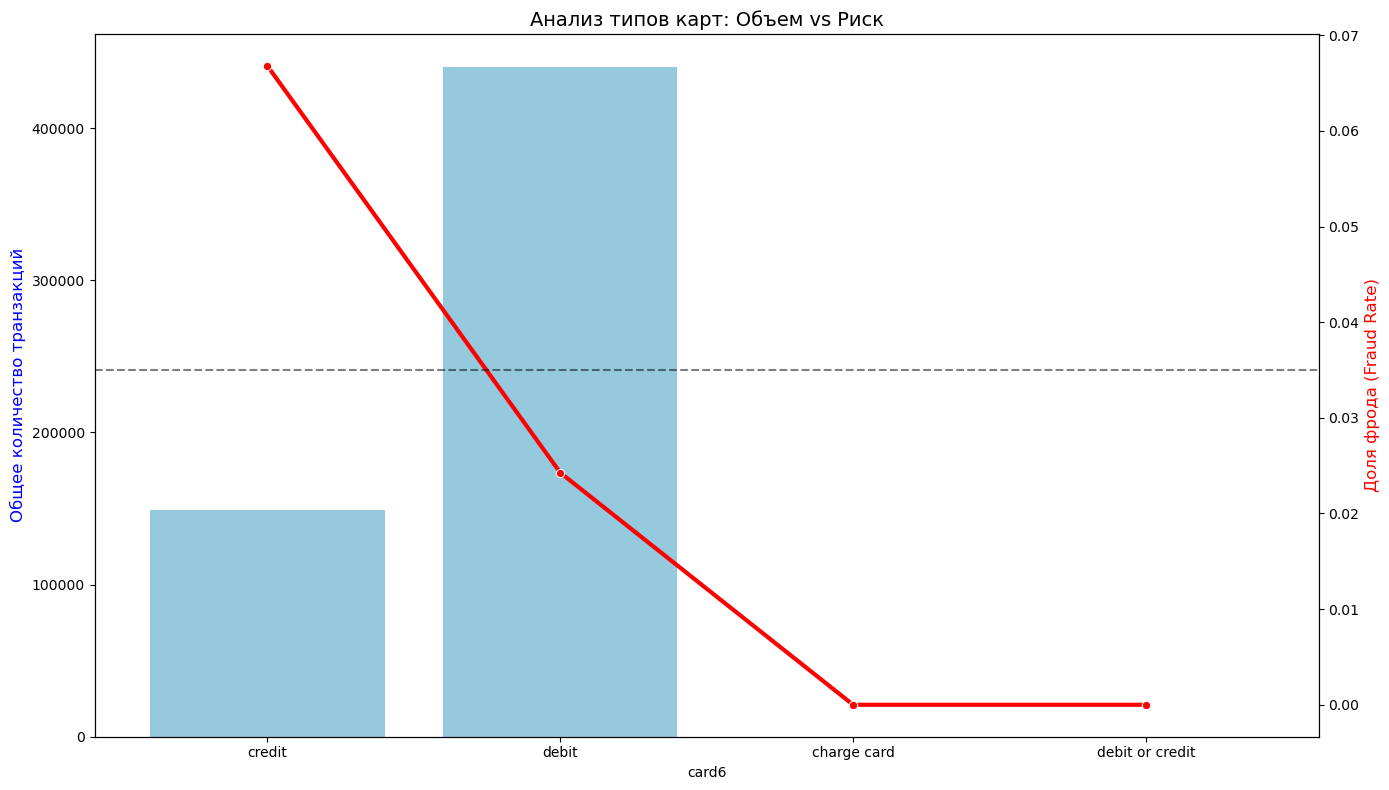

,card6,TotalTransactions,FraudRate
1,credit,148986,0.066785
2,debit,439938,0.024263
0,charge card,15,0.000000
3,debit or credit,30,0.000000


In [22]:
# Для типов карт (debit, credit)
card6_stats = eda_analysis(transaction, 'card6', 'типов карт')
display(card6_stats)

Сравнение типов платежных инструментов выявило фундаментальное различие в уровне риска между кредитными и дебетовыми картами.

**Ключевые выводы:**
* **Высокорисковый сегмент (Credit):** Кредитные карты демонстрируют уровень фрода **6.68%**, что почти вдвое превышает средний показатель (3.5%). Кредитные карты обычно имеют более высокие лимиты, что привлекает мошенников. Тип карты `credit` один из сильнейших предикторов для антифрод-системы. 
* **Доверительный сегмент (Debit):** Самая массовая категория транзакций характеризуется минимальным уровнем риска (**2.43%**). Мошенники реже используют их, так как баланс на них ограничен личными средствами пользователя.Высокая концентрация легитимных операций в этом сегменте позволяет системе применять менее строгие фильтры для дебетовых карт, снижая количество ложных срабатываний.
* **Малозначимые категории:** Типы `charge card` и `debit or credit` имеют единичные вхождения и не оказывают влияния на общую статистику рисков.


## Анализ почтовых доменов покупателя (P_emaildomain)

In [23]:
# всего разных почтовых доменов
transaction['P_emaildomain'].nunique()

59

In [24]:
# количество почт в каждом почтовом домене
transaction['P_emaildomain'].value_counts()

P_emaildomain
gmail.com           228355
yahoo.com           100934
hotmail.com          45250
anonymous.com        36998
aol.com              28289
comcast.net           7888
icloud.com            6267
outlook.com           5096
msn.com               4092
att.net               4033
live.com              3041
sbcglobal.net         2970
verizon.net           2705
ymail.com             2396
bellsouth.net         1909
yahoo.com.mx          1543
me.com                1522
cox.net               1393
optonline.net         1011
charter.net            816
live.com.mx            749
rocketmail.com         664
mail.com               559
earthlink.net          514
gmail                  496
outlook.es             438
mac.com                436
juno.com               322
aim.com                315
hotmail.es             305
roadrunner.com         305
windstream.net         305
hotmail.fr             295
frontier.com           280
embarqmail.com         260
web.de                 240
netzero.com   

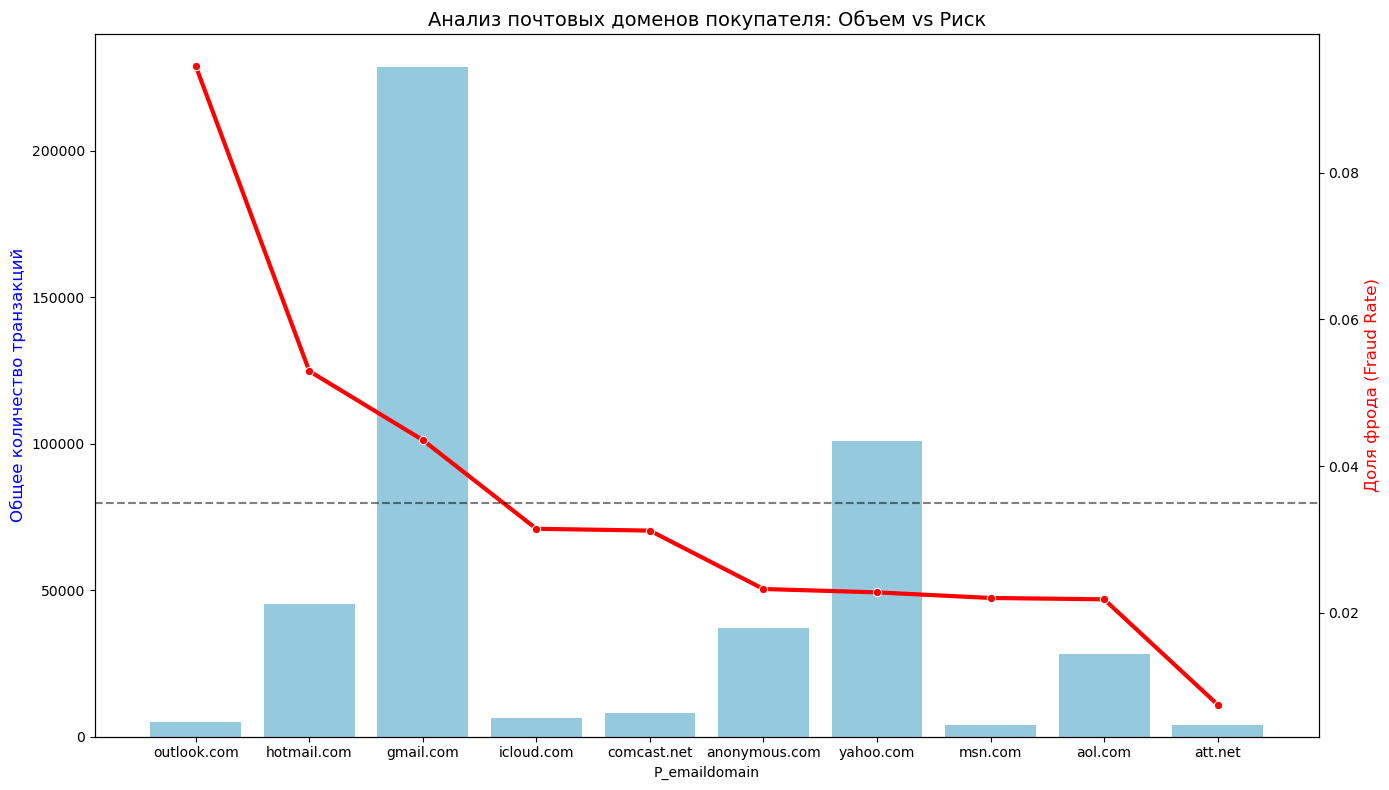

,P_emaildomain,TotalTransactions,FraudRate
8,outlook.com,5096,0.094584
5,hotmail.com,45250,0.052950
4,gmail.com,228355,0.043542
6,icloud.com,6267,0.031434
3,comcast.net,7888,0.031187
0,anonymous.com,36998,0.023217
9,yahoo.com,100934,0.022757
7,msn.com,4092,0.021994
1,aol.com,28289,0.021811
2,att.net,4033,0.007439


In [25]:
# Для почтовых доменов (Топ-10 по доле фрода)
p_email_stats = eda_analysis(transaction, 'P_emaildomain', 'почтовых доменов покупателя', is_top=True)
display(p_email_stats)

Исследование почтовых сервисов выявило четкую корреляцию между выбором домена и вероятностью мошенничества. На графике представлено топ-10 почтовых доменов с наибольшей долей фрода.

**Ключевые выводы:**
* **Сегмент экстремального риска:** Почтовые домены компании Microsoft (**outlook.com** — 9.46%, **hotmail.com** — 5.29%) демонстрируют аномально высокую концентрацию фрода. 
* **Anonymous.com:** Несмотря на название, домен показывает умеренный риск (2.3%), что может быть следствием особенностей анонимизации данных в самом датасете.

### Анализ влияния отсутствия почтового домена на риск (P_emaildomain)

In [26]:
# доля пропусков в поле P_emaildomain
round(transaction['P_emaildomain'].isnull().mean() * 100, 2)

15.99

In [27]:
# Создаем временный признак "Почта отсутствует" (True/False)
is_email_nan = transaction['P_emaildomain'].isnull()

# Считаем Fraud Rate для обеих групп
email_missing_analysis = transaction.groupby(is_email_nan)['isFraud'].agg(['count', 'mean']).reset_index()
email_missing_analysis.columns = ['is_email_missing', 'total_transactions', 'fraud_rate']

# Приводим к красивому виду
email_missing_analysis['is_email_missing'] = email_missing_analysis['is_email_missing'].map({True: 'Пропущена (NaN)', False: 'Почта указана'})

print('Влияния отсутствия почтового домена на риск')
display(email_missing_analysis)

Влияния отсутствия почтового домена на риск


,is_email_missing,total_transactions,fraud_rate
0,Почта указана,496084,0.036028
1,Пропущена (NaN),94456,0.029538


Проведено сравнение уровней мошенничества в зависимости от наличия данных в поле `P_emaildomain`. Примерно в **16%** транзакций почта отсутствует. 

**Результаты:**
* **Почта указана:** Fraud Rate = **3.60%** (на выборке из 496 084 транзакций).
* **Почта отсутствует (NaN):** Fraud Rate = **2.95%** (на выборке из 94 456 транзакций).

**Интерпретация для системы антифрода:**
* Обнаружена обратная зависимость: транзакции с заполненным полем email статистически **более рискованны**, чем анонимные операции.
* **Гипотеза:** Мошенники целенаправленно используют почтовые ящики для имитации легитимного поведения и обхода базовых правил проверки. Сам факт наличия email не является признаком доверия; критическое значение имеет репутация конкретного домена (как было показано ранее на примере `outlook.com`).
* **Вывод:** Отсутствие почты в данном наборе данных не является "красным флагом", а скорее указывает на использование упрощенных методов оплаты добросовестными клиентами.

## Анализ R_emaildomain в контексте категорий продуктов
Поле `R_emaildomain`(почтовый домен получателя) заполняется в случае, если покупатель и получатель разные лица (например, покупка в подарок). Проверим, для каких категорий товаров это наиболее актуально, и как такие покупки влияют на риск.

In [28]:
# доля пропусков в поле P_emaildomain
round(transaction['R_emaildomain'].isnull().mean() * 100, 2)

76.75

In [29]:
# Создаем флаг: заполнено ли поле R_emaildomain
transaction['has_R_email'] = transaction['R_emaildomain'].notnull()

# Считаем общую статистику
r_email_summary = transaction.groupby('has_R_email')['isFraud'].agg(['count', 'mean']).reset_index()
r_email_summary.columns = ['Почта получателя (R)', 'total_transactions', 'fraud_rate']

# Форматируем для вывода
r_email_summary['Почта получателя (R)'] = r_email_summary['Почта получателя (R)'].map({True: 'Указана', False: 'Пропущена (NaN)'})

display(r_email_summary)

,Почта получателя (R),total_transactions,fraud_rate
0,Пропущена (NaN),453249,0.020819
1,Указана,137291,0.081775


In [30]:
# Считаем статистику в разрезе ProductCD
r_email_analysis = transaction.groupby('ProductCD').agg(
    total_trans=('isFraud', 'count'),
    has_R_count=('has_R_email', 'sum'),
    fraud_with_R=('isFraud', lambda x: x[transaction.loc[x.index, 'has_R_email']].mean()),
    fraud_without_R=('isFraud', lambda x: x[~transaction.loc[x.index, 'has_R_email']].mean())
).reset_index()

# Считаем процент заполненности для каждой категории
r_email_analysis['fill_rate_pct'] = (r_email_analysis['has_R_count'] / r_email_analysis['total_trans']) * 100

display(r_email_analysis.sort_values(by='fill_rate_pct', ascending=False))

,ProductCD,total_trans,has_R_count,fraud_with_R,fraud_without_R,fill_rate_pct
2,R,37699,37686,0.037839,0.000000,99.965516
0,C,68519,66366,0.115978,0.144450,96.857806
3,S,11628,11038,0.058978,0.059322,94.926041
1,H,33024,22201,0.065448,0.011180,67.226865
4,W,439670,0,NaN,0.020399,0.000000


In [31]:
# вывод расчитанной ранее таблицы рисков по категориям товаров
display(product_stats)

,ProductCD,TotalTransactions,FraudRate
0,C,68519,0.116873
3,S,11628,0.058996
1,H,33024,0.047662
2,R,37699,0.037826
4,W,439670,0.020399


Исследование показало, что наличие данных о получателе платежа (`R_emaildomain`) жестко детерминировано типом продукта и является критическим индикатором риска.

**Ключевые выводы:**
* **Маркер высокого риска:** Транзакции с заполненным `R_emaildomain` имеют средний уровень фрода **8.18%**, что значительно превышает базовый уровень в 3.5%. 
* **Специализация категорий:** 
    * В категориях **R, C, S** наличие почты получателя является стандартным атрибутом, при этом категории C и S характеризуются высоким уровнем мошенничества: 11,7 % и 4,8% соотвественно.
    * В категории **H** наличие почты получателя увеличивает вероятность фрода почти в **6 раз** (с 1.1% до 6.5%).
* **Отсутствие в категории W** - для категории W данный признак не актуален (заполняемость 0%).

## Анализ влияния данных Identity на вероятность фрода

In [32]:
# Объединяем таблицы (how='left' сохраняет все транзакции)
# Таблица identity присоединяется по TransactionID
df = pd.merge(transaction, identity, on='TransactionID', how='left', indicator=True)

# indicator=True создал колонку '_merge'. 
# На её основе создаем понятный флаг 'has_identity'
df['has_identity'] = df['_merge'] == 'both'

# Удаляем служебную колонку _merge
df.drop('_merge', axis=1, inplace=True)


print(f"Размер таблицы df: {df.shape}")

Размер таблицы df: (590540, 436)


In [33]:
# Количество признаков больше на 2 по сравнению с исходными данными, 
# из-за новых признаков has_R_email и has_identity. 
# Они оставлены намерено, для расчета кореляции в следующем пункте.
with pd.option_context('display.max_columns', None):
    display(df.head())

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,has_R_email,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,has_identity
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.

In [34]:
# Анализируем влияние наличия Identity на риск
identity_impact = df.groupby('has_identity')['isFraud'].agg(['count', 'mean']).reset_index()
identity_impact.columns = ['has_identity', 'total_transactions', 'fraud_rate']

display(identity_impact)

,has_identity,total_transactions,fraud_rate
0,False,446307,0.020939
1,True,144233,0.078470


Результаты объединения таблиц `Transaction` и `Identity` выявили критическую зависимость между наличием технического "отпечатка" устройства и уровнем риска.

**Вывод:** Транзакции, имеющие запись в таблице Identity, в **3.75 раза опаснее** анонимных операций (риск 7.85% против 2.09%).  
**Гипотеза:**  Наличие `Identity` связано с определенными категориями товаров.

### Связь наличия данных Identity с категорией товара

In [35]:
#  Группируем данные по категориям и смотрим, есть ли там Identity
identity_by_product = df.groupby('ProductCD').agg(
    total_trans=('isFraud', 'count'),
    with_id_count=('has_identity', 'sum'),
    fraud_with_id=('isFraud', lambda x: x[df.loc[x.index, 'has_identity']].mean()),
    fraud_without_id=('isFraud', lambda x: x[~df.loc[x.index, 'has_identity']].mean())
).reset_index()

# Считаем % заполненности Identity для каждой категории
identity_by_product['id_fill_rate_pct'] = (identity_by_product['with_id_count'] / identity_by_product['total_trans']) * 100

display(identity_by_product.sort_values(by='id_fill_rate_pct', ascending=False))

,ProductCD,total_trans,with_id_count,fraud_with_id,fraud_without_id,id_fill_rate_pct
1,H,33024,32908,0.047739,0.025862,99.648740
3,S,11628,11585,0.059042,0.046512,99.630203
2,R,37699,37548,0.037898,0.019868,99.599459
0,C,68519,62192,0.122845,0.058163,90.766065
4,W,439670,0,NaN,0.020399,0.000000


Анализ связи `Identity` и `ProductCD` выявил аномалию: наличие данных об устройстве коррелирует с **повышенным** уровнем фрода внутри одной и той же категории.

**Ключевые выводы:**
* **Сегментация по риску:** В категории **C** (самой рискованной) транзакции с данными Identity имеют Fraud Rate **12.2%**, в то время как без них — лишь **5.8%**. 
* **Бизнес-логика системы:** Категория **W** (вероятно, физические товары) полностью исключена из процесса сбора технических метаданных устройства. Напротив, категории **H, S, R, C** покрыты идентификацией на 90%+. 
* **Гипотеза:** Небольшая доля транзакций в рискованых категориях, прошедшая без фиксации данных в таблице Identity, вероятно, принадлежит повторным и верифицированным клиентам. Для этой группы система безопасности намеренно пропускает шаг сканирования устройства. Это объясняет, почему транзакции без Identity внутри одной и той же категории продукта обладают меньшим уровнем риска.

In [36]:
# Проверяем, есть ли почта покупателя в категории W
w_email_check = transaction[transaction['ProductCD'] == 'W']['P_emaildomain'].isnull().mean() * 100
print(f"Процент пропусков почты в категории W: {w_email_check:.2f}%")

Процент пропусков почты в категории W: 18.34%


### Примечание по категории товаров W

На основании проведенного анализа можно предположить, что товары категории W имеют признаки, характерные для офлайн-сектора:
*  **Отсутствие технических метаданных:** Нулевой показатель заполненности таблицы Identity (0%) типичен для оплаты через физические POS-терминалы, которые не фиксируют параметры устройства или браузера.
*  **Низкий уровень риска:** Низкая доля фрода может объясняться необходимостью физического присутствия держателя карты при совершении транзакции.

Однако однозначно утверждать о принадлежности категории W к офлайн-сектору невозможно по следующим причинам:
*  **Наличие контактных данных:** У большинства транзакций в этой категории заполнено поле почтового домена (~82%), что нехарактерно для классических покупок на кассе, но является стандартом для e-commerce.
*  **Специализация поставщика данных:** Компания Vesta Corporation специализируется на защите транзакций в сфере цифрового ритейла и онлайн-услуг (Card-Not-Present).

## Анализ корреляции признаков

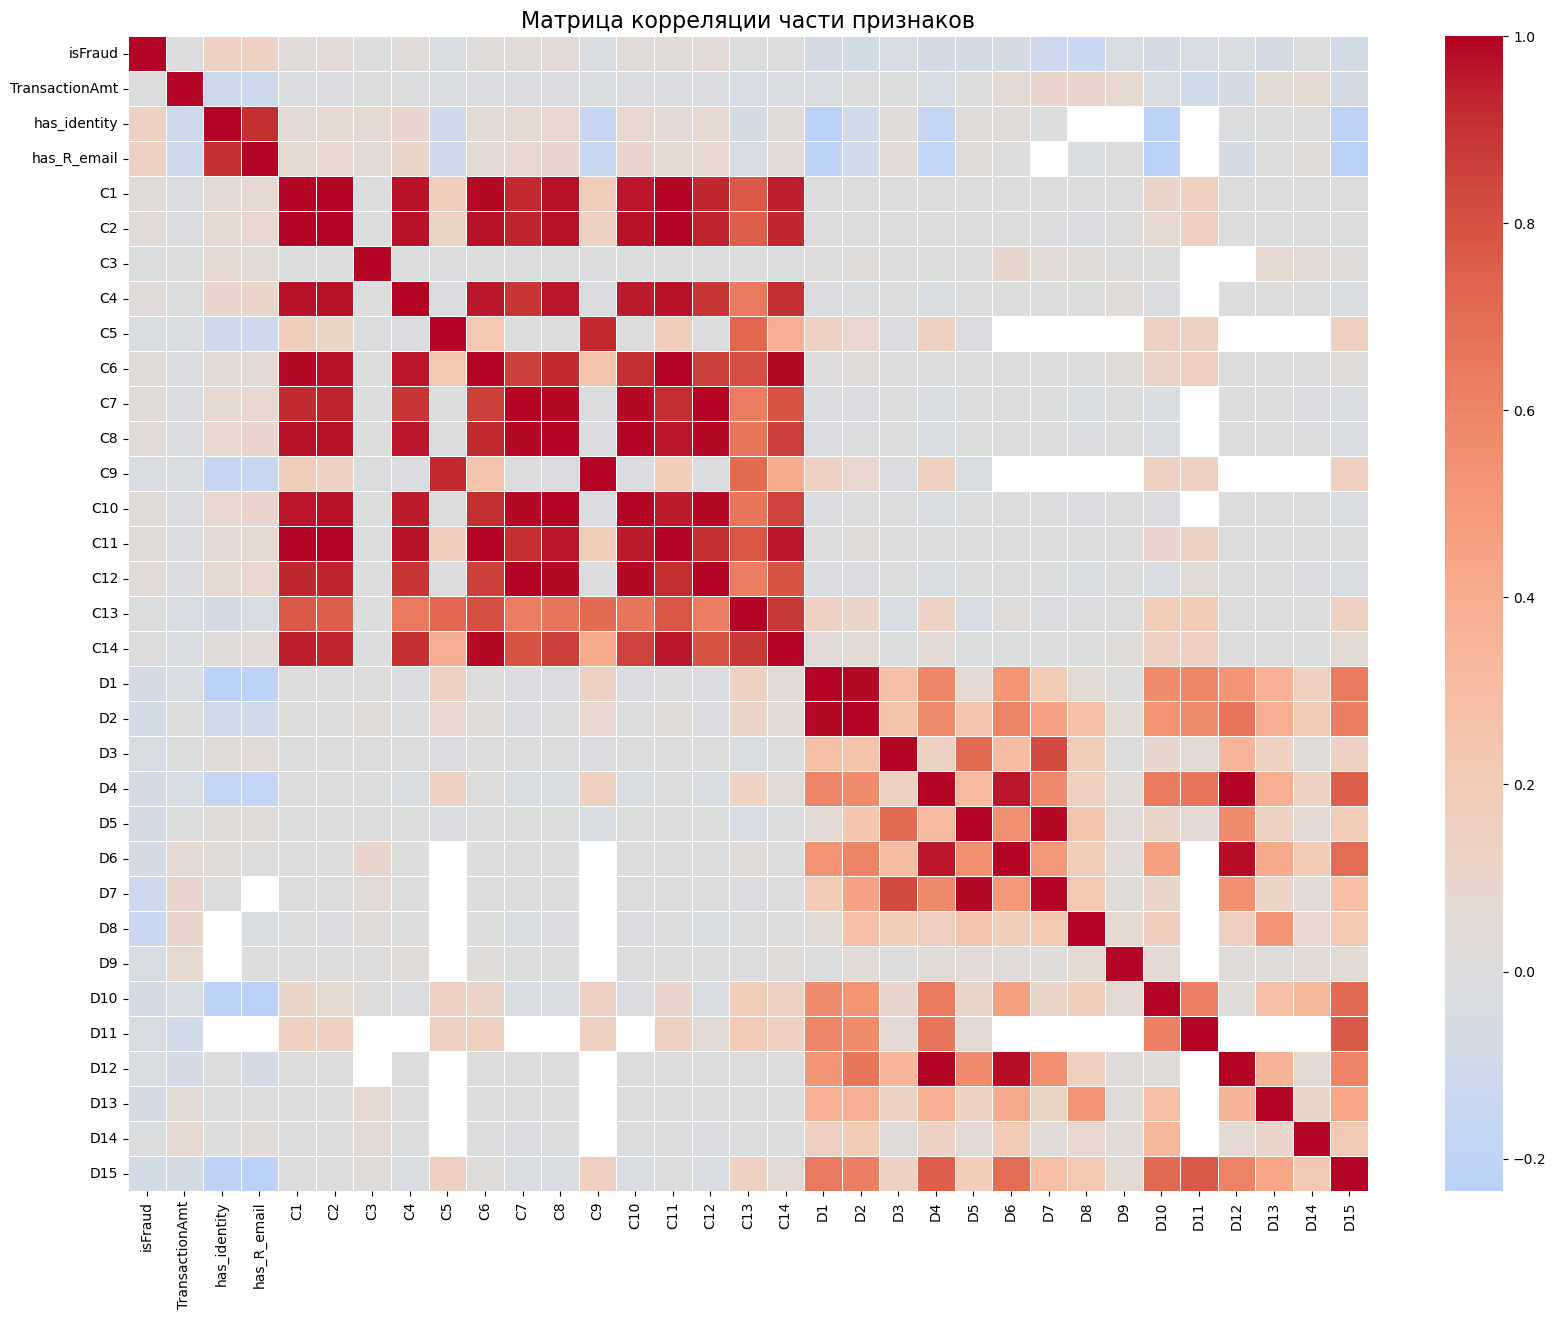

In [37]:
# Выбираем часть признаков, так как отображение всего датасета будет нечитаемым из-за большого количества признаков
c_cols = [f'C{i}' for i in range(1, 15)]
d_cols = [f'D{i}' for i in range(1, 16)]
base_cols = ['isFraud','TransactionAmt','has_identity','has_R_email']

cols_to_corr = base_cols + c_cols + d_cols

# Считаем корреляцию Пирсона
corr_matrix = df[cols_to_corr].corr()

# Визуализация
plt.figure(figsize=(20, 15))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Матрица корреляции части признаков', fontsize=16)
plt.show()

In [38]:
# Поиск пар с высокой корреляцией
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [(column, row) for column in upper.columns for row in upper.index if upper[column][row] > 0.95]

print(f"Найдено пар с корреляцией > 0.95: {len(high_corr_pairs)}")
for pair in high_corr_pairs[:10]: # Выведем первые 10 для примера
    print(f"{pair[0]} <-> {pair[1]}: {corr_matrix.loc[pair[0], pair[1]]:.4f}")

Найдено пар с корреляцией > 0.95: 32
C2 <-> C1: 0.9951
C4 <-> C1: 0.9678
C4 <-> C2: 0.9721
C6 <-> C1: 0.9822
C6 <-> C2: 0.9748
C6 <-> C4: 0.9623
C8 <-> C1: 0.9677
C8 <-> C2: 0.9759
C8 <-> C4: 0.9600
C8 <-> C7: 0.9830


Выявлено 32 пары признаков с коэффициентом корреляции Пирсона выше **0.95**. 

**Ключевые выводы:**
* **Дублирование данных:** Пара **C1 <-> C2** имеет корреляцию **0.9951**, что делает их практически взаимозаменяемыми. Аналогичная ситуация наблюдается для C4, C6, C7 и C8.
* **Избыточность:** Высокая плотность связей внутри группы C показывает, что признаки описывают схожие поведенческие паттерны с минимальными различиями в логике подсчета.

**Feature Selection:** На следующем этапе планируется удаление части признаков с корреляцией > 0.95. Это критически важно для предотвращения переобучения на избыточных признаках. А также необходимо более изучить корреляцию между признаками не рассмотренными, в рамках данного анализа.

---

# 3. Оценка качества разметки

В датасете IEEE-CIS разметка является бинарной (isFraud: 0 или 1). Однако, специфика цифрового ритейла накладывает ряд ограничений на достоверность этих меток:
*  Проблема задержки (Chargeback Lag): В реальных условиях подтверждение фрода (чарджбэк) может занимать от 30 до 90 дней. В выборке, ограниченной 6 месяцами, транзакции последнего месяца могут иметь метку 0 (легитимная) просто потому, что жалоба от владельца карты еще не успела поступить в систему.
*  Мошенническая деятельность может не быть зарегистрирована, например, держатель карты не знал об этом или забыл сообщить вовремя по истечении срока подачи претензии. В таких случаях мошенническая операция будет помечена как законная, что создает шум.
*  Friendly Fraud (Дружелюбное мошенничество): Часть транзакций, помеченных как 1, технически являются легитимными (совершены реальным владельцем), но позже оспорены им для возврата средств. Это также создает шум.

## Проверка задержки разметки (Chargeback Lag)

Сначала проверим распределение данных по условным месяцам (информации о датах нет).

In [39]:
# 1. Переводим секунды в полные дни (86400 секунд в сутках)
transaction['day_idx'] = transaction['TransactionDT'] // 86400

# 2. Группируем по 31 дню
days_per_month = 31
transaction['month_idx'] = transaction['day_idx'] // days_per_month

# 3. Считаем статистику: сколько уникальных дней и какая доля фрода
month_check = transaction.groupby('month_idx').agg(
    total_days=('day_idx', 'nunique'),
    total_transactions=('isFraud', 'count'),
    fraud_rate=('isFraud', 'mean')
).reset_index()

print("Анализ полноты месяцев (по 31 дню)")
display(month_check)

Анализ полноты месяцев (по 31 дню)


,month_idx,total_days,total_transactions,fraud_rate
0,0,30,134339,0.025317
1,1,31,92510,0.039877
2,2,31,99337,0.039653
3,3,31,97270,0.039930
4,4,31,88542,0.033611
5,5,28,78542,0.035319


Датасет можно разделить на 6 примерно равных месяца.

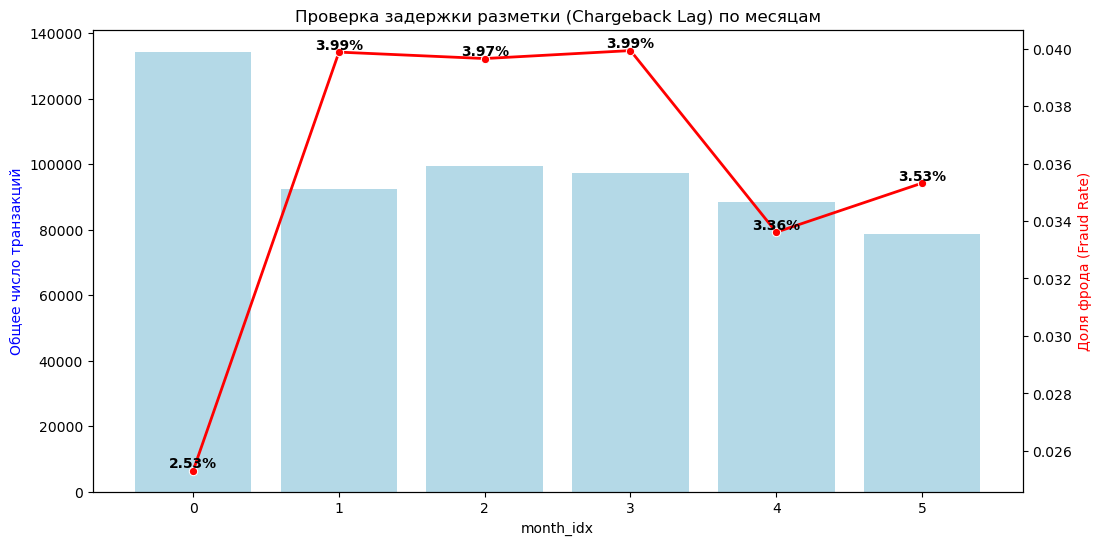

In [40]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Объем транзакций (бары) - используем month_check
sns.barplot(x='month_idx', y='total_transactions', data=month_check, ax=ax1, color='skyblue', alpha=0.7)
ax1.set_ylabel('Общее число транзакций', color='blue')
ax1.set_title('Проверка задержки разметки (Chargeback Lag) по месяцам')

# Доля фрода (линия)
ax2 = ax1.twinx()
# Сбрасываем индекс для lineplot, чтобы x совпадал с барами
sns.lineplot(x=ax1.get_xticks(), y=month_check['fraud_rate'], ax=ax2, marker='o', color='red', lw=2)
ax2.set_ylabel('Доля фрода (Fraud Rate)', color='red')

# Добавим подписи значений Fraud Rate на график
for i, rate in enumerate(month_check['fraud_rate']):
    ax2.text(i, rate, f'{rate:.2%}', color='black', va='bottom', ha='center', fontweight='bold')

plt.show()

# Удаляем временные колонки
transaction.drop(['day_idx', 'month_idx'], axis=1, inplace=True)

### Оценка стабильности разметки во времени

Анализ 31-дневных циклов позволил выявить специфические особенности формирования обучающей выборки:

1. **Аномалия старта (Месяц 0):** Доля фрода составляет всего **2.53%**, что на 35% ниже среднего уровня стабильных периодов.  
**Вывод:** Это может свидетельствовать о "холодном старте" системы сбора данных или о том, что в первый месяц транзакции из определенных высокорисковых категорий (например, ProductCD 'C') еще не были интегрированы в поток. Обучение на этом периоде может дать модели смещенное представление о "норме".

2. **Стабильный период (Месяцы 1, 2, 3):** Наблюдается плато на уровне **~3.9%**. Это наиболее качественные и репрезентативные данные для обучения паттернам мошенничества.

3. **Гипотеза Chargeback Lag (Месяцы 4, 5):** Хотя доля фрода незначительно снизилась до **3.3-3.5%**, это снижение не является критическим.  
**Вывод:** В данном датасете проблема задержки чарджбэков выражена слабо. Вероятно, организаторы IEEE-CIS провели предварительную очистку данных или выгрузили их спустя достаточное время после совершения транзакций.

**Решение для стратегии валидации:**
* **Месяц 0** признан потенциально зашумленным; на этапе Feature Engineering стоит проверить, не отличаются ли в нем распределения категориальных признаков.
* В качестве **Validation** будут использоваться последние 20% данных (Месяцы 4-5), так как, несмотря на небольшое снижение доли, они отражают наиболее "свежие" паттерны поведения, что критично для SME-сегмента.

### Примечание
Хотя для подобной задачи целесообразно проверить качество разметки, сравнивая таргеты разных транзакций по каждой карте (предполагая, что если по карте зафиксирован фрод, то и все последующие операции должны быть помечены так же), в данном датасете невозможно однозначно выделить уникальные карты или клиентов. Данные в столбцах `card1–card6` содержат лишь общую информацию (тип карты, платежная система и т. д.) и не включают номер самой карты. Персональная информация о клиентах также отсутствует.

---

# 4. Стратегия формирования выборки и валидации

## Метод разбиения
Для оценки качества модели выбрана стратегия **Hold-out валидации по времени**. Использование стандартного случайного перемешивания недопустимо, так как это приведет к "утечке данных из будущего" и переобучению модели на временных аномалиях.
Данные отсортированы по признаку `TransactionDT`. Обучение проводится на первых 80% данных, тестирование — на последних 20%.
Такая схема максимально точно воспроизводит работу системы в реальных условиях SME-ритейла, когда модель обучается на исторических транзакциях и предсказывает риск для новых, поступающих в реальном времени.

## **Целевые метрики** 
Основная оценка будет проводиться на отложенной (Validation) выборке с упором на **PR-AUC**, так как она наиболее устойчива к дисбалансу классов (3,5% фрода). Дополнительно будет использоваться **FPR** — необходимо контролировать долю ложных блокировок честных транзакций, так как такие блокировки негативно влияют на лояльность клиентов и прибыльность бизнеса.